In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Resizing
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from PIL import Image
import requests
from io import BytesIO

In [31]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [32]:
d = {0:	"airplane",
     1:	"automobile",
     2:	"bird",
     3:	"cat",
     4:	"deer",
     5:	"dog",
     6:	"frog",
     7:	"horse",
     8:	"ship",
     9:	"truck"}

In [33]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

In [34]:
x_train.shape

(50000, 32, 32, 3)

In [35]:
y_train.shape

(50000, 1)

In [36]:
y_train = y_train.reshape((-1,))

In [37]:
y_test = y_test.reshape((-1,))


In [38]:
y_train_cat = tf.keras.utils.to_categorical(y_train)
y_test_cat = tf.keras.utils.to_categorical(y_test)


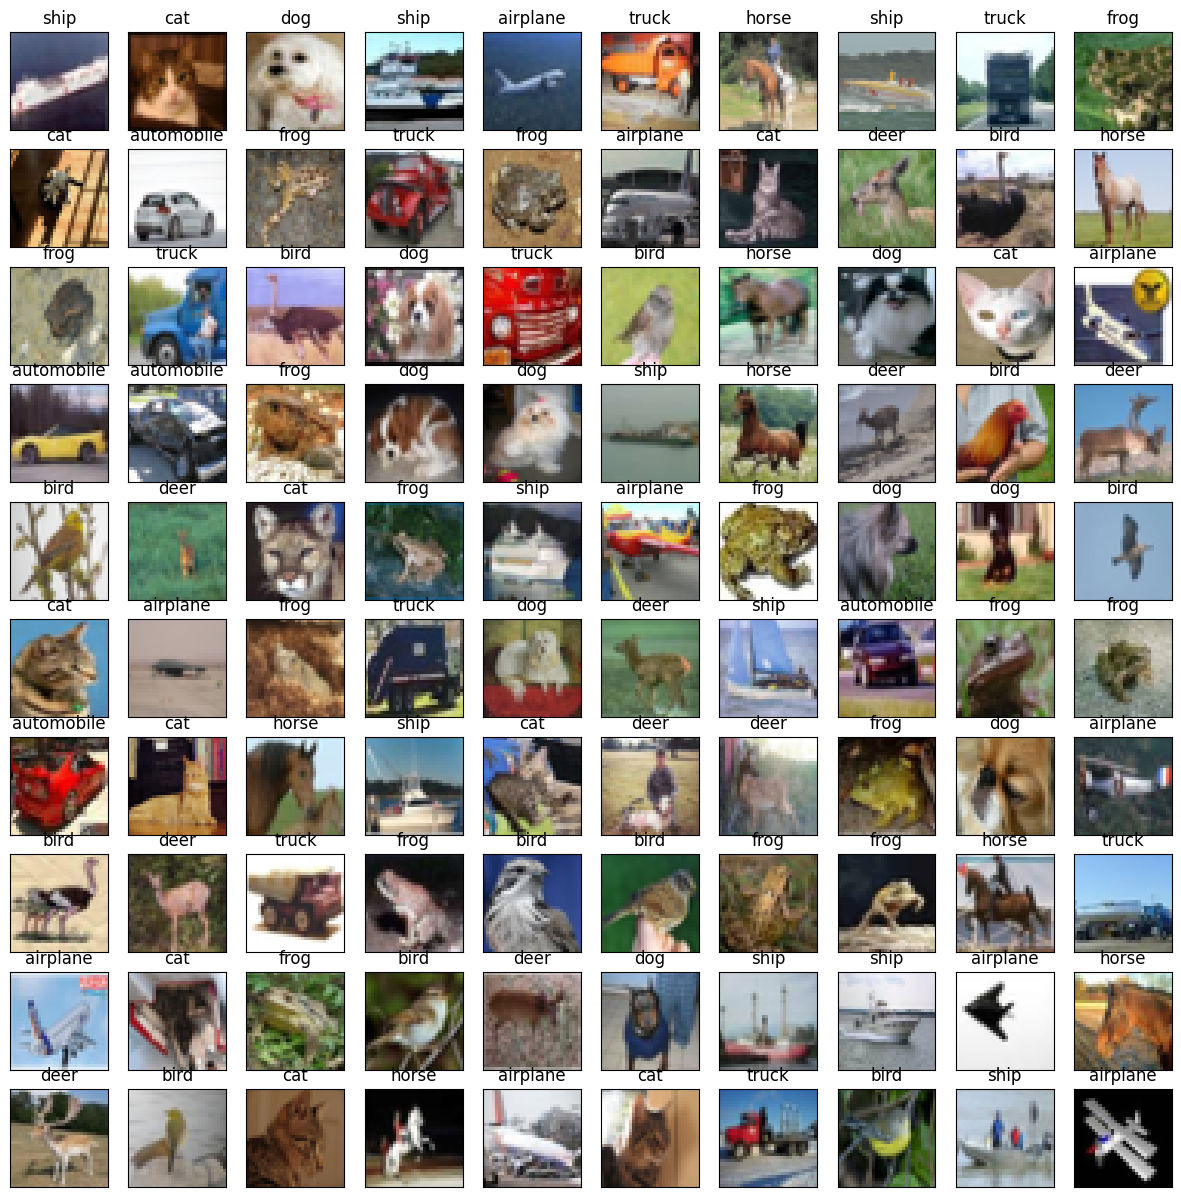

In [40]:
plt.figure(figsize=(15, 15))

for i in range(100):
    plt.subplot(10, 10, i + 1)
    ind = np.random.randint(0, 50000)
    plt.imshow(x_train[ind].astype("uint8"))
    plt.xticks([])
    plt.yticks([])
    plt.title(d[y_train[ind]])

plt.show()

In [41]:
IMG_SIZE = 64

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [42]:
inputs = Input(shape=(32, 32, 3))

x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

outputs = Dense(10, activation="softmax")(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 64, 64, 3) │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64, 64)    │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64, 64)    │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 64, 64)    │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 64, 64, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 2, 2, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      2,570 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_1 = model.fit(
    x_train,
    y_train_cat,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.6215 - loss: 1.5079 - val_accuracy: 0.7219 - val_loss: 0.8064
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.7221 - loss: 0.8180 - val_accuracy: 0.7462 - val_loss: 0.7425
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7511 - loss: 0.7233 - val_accuracy: 0.7529 - val_loss: 0.7293
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7697 - loss: 0.6701 - val_accuracy: 0.7645 - val_loss: 0.7107
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.7784 - loss: 0.6353 - val_accuracy: 0.7627 - val_loss: 0.7047
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7918 - loss: 0.5954 - val_accuracy: 0.7644 - val_loss: 0.7174
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7980 - loss: 0.5744 - val_accuracy: 0.7670 - val_loss: 0.7314
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8058 - loss: 0.5489 - 

In [46]:
base_model.trainable = True


for layer in base_model.layers:
    if "block5" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

In [47]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model.fit(
    x_train,
    y_train_cat,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 72ms/step - accuracy: 0.8507 - loss: 0.4266 - val_accuracy: 0.8043 - val_loss: 0.6581
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.8856 - loss: 0.3171 - val_accuracy: 0.8112 - val_loss: 0.6442
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9076 - loss: 0.2526 - val_accuracy: 0.8207 - val_loss: 0.6432
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9226 - loss: 0.2108 - val_accuracy: 0.8234 - val_loss: 0.6664
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9374 - loss: 0.1713 - val_accuracy: 0.8316 - val_loss: 0.6419
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9468 - loss: 0.1481 - val_accuracy: 0.8386 - val_loss: 0.6516
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9560 - loss: 0.1249 - val_accuracy: 0.8432 - val_loss: 0.6626
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9614 - loss: 0.1080 - 

In [48]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8462 - loss: 0.7181
Test loss: 0.7181463241577148
Test accuracy: 0.8461999893188477


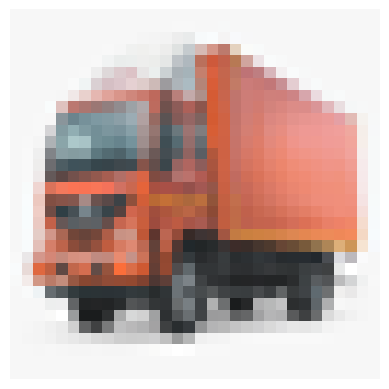

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
Predicted class: truck
Confidence: 100.0 %


In [49]:
response = requests.get("https://vamosys.com/wp-content/uploads/2022/02/container-truck.png")
img = Image.open(BytesIO(response.content))

img = img.resize((32, 32)).convert("RGB")
img_array = np.array(img).astype("float32")

plt.imshow(img_array.astype("uint8"))
plt.axis("off")
plt.show()

img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

class_id = np.argmax(pred)
confidence = np.max(pred) * 100

print("Predicted class:", d[class_id])
print("Confidence:", confidence, "%")

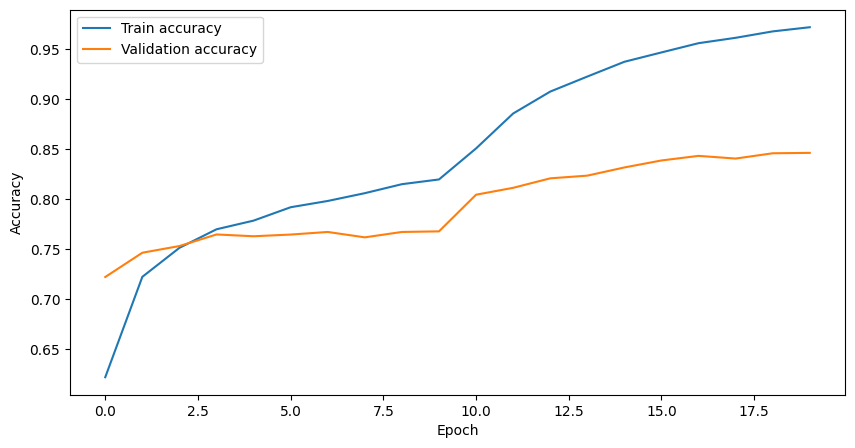

In [50]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

plt.figure(figsize=(10, 5))
plt.plot(acc, label="Train accuracy")
plt.plot(val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

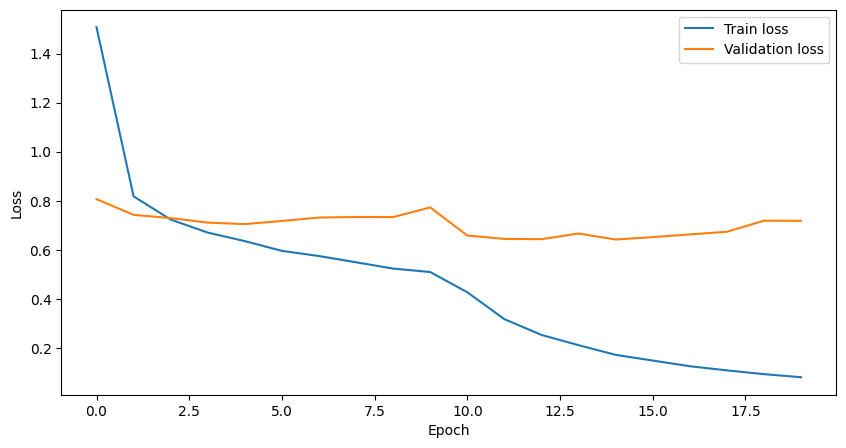

In [51]:
loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]

plt.figure(figsize=(10, 5))
plt.plot(loss, label="Train loss")
plt.plot(val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()